## Section 1: Environment Setup and Imports (Google Colab)

In [1]:
# Bootstrap imports and defaults so early cells can execute safely even before later setup cells.
import os
import io
import warnings
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')


def _first_existing_path(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


def _first_existing_file(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.isfile(p):
            return p
    return None


# Minimal defaults so cells appearing before the later configuration block can run.
RANDOM_SEED = globals().get('RANDOM_SEED', 42)
USE_PREDEFINED_TRAIN_TEST = globals().get('USE_PREDEFINED_TRAIN_TEST', True)
DATASET_NAME = globals().get('DATASET_NAME', 'weibo')  # 'weibo' or 'twitter'

_default_roots = [
    f'/content/drive/MyDrive/Godimedia/{DATASET_NAME.lower()}',
    f'/content/{DATASET_NAME.lower()}',
    f'/content/drive/MyDrive/{DATASET_NAME.lower()}',
    f'c:/Users/mestr/OneDrive/Documents/Godimedia/{DATASET_NAME.lower()}',
    f'./{DATASET_NAME.lower()}',
]
DATA_ROOT = globals().get('DATA_ROOT', _first_existing_path(_default_roots) or _default_roots[0])

if DATASET_NAME.lower() == 'weibo':
    _train_csv_candidates = [
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train.csv'),
        os.path.join(DATA_ROOT, 'train_posts.csv'),
    ]
    _test_csv_candidates = [
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test.csv'),
        os.path.join(DATA_ROOT, 'test_posts.csv'),
    ]
    _image_dir_candidates = [
        os.path.join(DATA_ROOT, 'images'),
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'rumor_images'),
        os.path.join(DATA_ROOT, 'nonrumor_images'),
    ]
else:
    _train_csv_candidates = [
        os.path.join(DATA_ROOT, 'train_posts.csv'),
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
    ]
    _test_csv_candidates = [
        os.path.join(DATA_ROOT, 'test_posts.csv'),
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
    ]
    _image_dir_candidates = [
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'images'),
    ]

TRAIN_CSV_PATH = globals().get('TRAIN_CSV_PATH', _first_existing_file(_train_csv_candidates) or _train_csv_candidates[0])
TEST_CSV_PATH = globals().get('TEST_CSV_PATH', _first_existing_file(_test_csv_candidates) or _test_csv_candidates[0])
CSV_PATH = globals().get('CSV_PATH', TRAIN_CSV_PATH)

_resolved_images_dir = _first_existing_path(_image_dir_candidates)
IMAGES_TRAIN_DIR = globals().get('IMAGES_TRAIN_DIR', _resolved_images_dir or os.path.join(DATA_ROOT, 'images_train'))
IMAGES_TEST_DIR = globals().get('IMAGES_TEST_DIR', _resolved_images_dir or os.path.join(DATA_ROOT, 'images_test'))

EXTRA_IMAGE_DIRS = globals().get(
    'EXTRA_IMAGE_DIRS',
    [
        p for p in [
            os.path.join(DATA_ROOT, 'images'),
            os.path.join(DATA_ROOT, 'rumor_images'),
            os.path.join(DATA_ROOT, 'nonrumor_images'),
            os.path.join(DATA_ROOT, 'images_train'),
            os.path.join(DATA_ROOT, 'images_test'),
        ]
        if os.path.isdir(p)
    ]
)

TEXT_COLUMN = globals().get('TEXT_COLUMN', 'post_text')
IMAGE_ID_COLUMN = globals().get('IMAGE_ID_COLUMN', 'image_id')
IMAGE_COLUMN = globals().get('IMAGE_COLUMN', 'image_path')
LABEL_COLUMN = globals().get('LABEL_COLUMN', 'label')
IMAGE_SIZE = globals().get('IMAGE_SIZE', (224, 224))
IMAGE_RESIZE_TIMEOUT = globals().get('IMAGE_RESIZE_TIMEOUT', 10)
IMAGE_EXT_CANDIDATES = globals().get('IMAGE_EXT_CANDIDATES', ['.jpg', '.jpeg', '.png', '.gif', '.webp', '.bmp'])
TEST_SIZE = globals().get('TEST_SIZE', 0.2)
VALIDATION_SPLIT = globals().get('VALIDATION_SPLIT', 0.1)
TEXT_MAX_FEATURES = globals().get('TEXT_MAX_FEATURES', 5000)
TEXT_NGRAM_RANGE = globals().get('TEXT_NGRAM_RANGE', (1, 2))
TEXT_REDUCTION_COMPONENTS = globals().get('TEXT_REDUCTION_COMPONENTS', 512 if DATASET_NAME.lower() == 'weibo' else 300)
TEXT_ENCODER_BATCH_SIZE = globals().get('TEXT_ENCODER_BATCH_SIZE', 32)
PCA_N_COMPONENTS = globals().get('PCA_N_COMPONENTS', 50)
LDA_N_COMPONENTS = globals().get('LDA_N_COMPONENTS', 30)
MLP_HIDDEN_LAYER_SIZES = globals().get('MLP_HIDDEN_LAYER_SIZES', (100, 50))
MLP_ACTIVATION = globals().get('MLP_ACTIVATION', 'relu')
MLP_LEARNING_RATE = globals().get('MLP_LEARNING_RATE', 0.001)
MLP_MAX_ITERATIONS = globals().get('MLP_MAX_ITERATIONS', 500)
MLP_EARLY_STOPPING = globals().get('MLP_EARLY_STOPPING', True)
DT_MAX_DEPTH = globals().get('DT_MAX_DEPTH', 15)
DT_MIN_SAMPLES_SPLIT = globals().get('DT_MIN_SAMPLES_SPLIT', 5)
DT_MIN_SAMPLES_LEAF = globals().get('DT_MIN_SAMPLES_LEAF', 2)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✓ Bootstrap imports loaded')
print(f'✓ Dataset: {DATASET_NAME}')
print(f'✓ Default data root: {DATA_ROOT}')
print(f'✓ Train CSV: {TRAIN_CSV_PATH}')
print(f'✓ Test CSV: {TEST_CSV_PATH}')
print(f'✓ Images dir(train): {IMAGES_TRAIN_DIR}')
print(f'✓ Images dir(test): {IMAGES_TEST_DIR}')
print(f'✓ Extra image dirs: {EXTRA_IMAGE_DIRS}')
print(f'✓ Text reduction components: {TEXT_REDUCTION_COMPONENTS}')
print(f'✓ Default image size: {IMAGE_SIZE}')

✓ Bootstrap imports loaded
✓ Dataset: weibo
✓ Default data root: /content/drive/MyDrive/Godimedia/weibo
✓ Train CSV: /content/drive/MyDrive/Godimedia/weibo/df_train2.csv
✓ Test CSV: /content/drive/MyDrive/Godimedia/weibo/df_test2.csv
✓ Images dir(train): /content/drive/MyDrive/Godimedia/weibo/images_train
✓ Images dir(test): /content/drive/MyDrive/Godimedia/weibo/images_test
✓ Extra image dirs: []
✓ Text reduction components: 512
✓ Default image size: (224, 224)


In [2]:
# ============================================================================
# COLAB SETUP: MOUNT GOOGLE DRIVE (RUN THIS FIRST ON COLAB)
# ============================================================================

IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✓ Google Drive mounted at /content/drive')
else:
    print('Not running in Colab; skipping Drive mount.')

# Optional quick visibility check for your expected folder.
expected_weibo_root = '/content/drive/MyDrive/Godimedia/weibo'
if os.path.exists(expected_weibo_root):
    print(f'✓ Found expected Weibo folder: {expected_weibo_root}')
else:
    print(f'⚠ Weibo folder not found at: {expected_weibo_root}')
    print('  If needed, upload/copy folder to MyDrive/Godimedia/weibo or set DATA_ROOT manually.')

Mounted at /content/drive
✓ Google Drive mounted at /content/drive
✓ Found expected Weibo folder: /content/drive/MyDrive/Godimedia/weibo


## Section 2: Configuration, Reproducibility, and File Paths

In [3]:
# ============================================================================
# GLOBAL CONFIGURATION & REPRODUCIBILITY SETTINGS
# ============================================================================

# --- RANDOM SEED FOR REPRODUCIBILITY ---
RANDOM_SEED = 42

def set_seed(seed: int):
    """Set random seeds for deterministic behavior as much as possible."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

# --- DATASET SELECTION ---
# Supported values: 'weibo', 'twitter'
DATASET_NAME = 'weibo'

# --- DATASET MODE ---
# True  -> Use provided train/test CSV files directly
# False -> Use one CSV and split inside notebook
USE_PREDEFINED_TRAIN_TEST = True


def _pick_existing_path(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


def _pick_existing_file(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.isfile(p):
            return p
    return None


# --- AUTO-DETECT DATA ROOT (LOCAL OR COLAB) ---
if DATASET_NAME.lower() == 'weibo':
    CANDIDATE_DATA_ROOTS = [
        '/content/drive/MyDrive/Godimedia/weibo',
        '/content/weibo',
        '/content/drive/MyDrive/weibo',
        'c:/Users/mestr/OneDrive/Documents/Godimedia/weibo',
        './weibo',
    ]
else:
    CANDIDATE_DATA_ROOTS = [
        '/content/drive/MyDrive/Godimedia/twitter',
        '/content/twitter',
        '/content/drive/MyDrive/twitter',
        'c:/Users/mestr/OneDrive/Documents/Godimedia/twitter',
        './twitter',
    ]

DATA_ROOT = _pick_existing_path(CANDIDATE_DATA_ROOTS) or f'/content/{DATASET_NAME.lower()}'

# --- PATHS (AUTO-RESOLVE COMMON FILE NAMES) ---
if DATASET_NAME.lower() == 'weibo':
    train_candidates = [
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train.csv'),
        os.path.join(DATA_ROOT, 'train_posts.csv'),
    ]
    test_candidates = [
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test.csv'),
        os.path.join(DATA_ROOT, 'test_posts.csv'),
    ]
    image_dir_candidates = [
        os.path.join(DATA_ROOT, 'images'),
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'rumor_images'),
        os.path.join(DATA_ROOT, 'nonrumor_images'),
    ]
else:
    train_candidates = [
        os.path.join(DATA_ROOT, 'train_posts.csv'),
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
    ]
    test_candidates = [
        os.path.join(DATA_ROOT, 'test_posts.csv'),
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
    ]
    image_dir_candidates = [
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'images'),
    ]

TRAIN_CSV_PATH = _pick_existing_file(train_candidates) or train_candidates[0]
TEST_CSV_PATH = _pick_existing_file(test_candidates) or test_candidates[0]
CSV_PATH = TRAIN_CSV_PATH  # used only if USE_PREDEFINED_TRAIN_TEST=False

resolved_image_dir = _pick_existing_path(image_dir_candidates)
IMAGES_TRAIN_DIR = resolved_image_dir or os.path.join(DATA_ROOT, 'images_train')
IMAGES_TEST_DIR = resolved_image_dir or os.path.join(DATA_ROOT, 'images_test')

EXTRA_IMAGE_DIRS = [
    p for p in [
        os.path.join(DATA_ROOT, 'images'),
        os.path.join(DATA_ROOT, 'rumor_images'),
        os.path.join(DATA_ROOT, 'nonrumor_images'),
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
    ]
    if os.path.isdir(p)
]

TWEETS_DIR_CANDIDATES = [
    os.path.join(DATA_ROOT, 'tweets'),
    os.path.join(DATA_ROOT, 'tweet'),
]
TWEETS_DIR = _pick_existing_path(TWEETS_DIR_CANDIDATES)

# --- COLUMN MAPPING (AUTO-RESOLVED IN LOADER; THESE ARE FALLBACKS) ---
TEXT_COLUMN = 'post_text'
IMAGE_ID_COLUMN = 'image_id'
IMAGE_COLUMN = 'image_path'   # derived column created in loader
LABEL_COLUMN = 'label'

# --- IMAGE PROCESSING CONFIGURATION ---
IMAGE_SIZE = (224, 224)
IMAGE_RESIZE_TIMEOUT = 10
IMAGE_EXT_CANDIDATES = ['.jpg', '.jpeg', '.png', '.gif', '.webp', '.bmp']

# --- MODEL HYPERPARAMETERS ---
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.1

TEXT_MAX_FEATURES = 5000
TEXT_NGRAM_RANGE = (1, 2)
TEXT_REDUCTION_COMPONENTS = 512 if DATASET_NAME.lower() == 'weibo' else 300
TEXT_ENCODER_BATCH_SIZE = 32

PCA_N_COMPONENTS = 50
LDA_N_COMPONENTS = 30

MLP_HIDDEN_LAYER_SIZES = (100, 50)
MLP_ACTIVATION = 'relu'
MLP_LEARNING_RATE = 0.001
MLP_MAX_ITERATIONS = 500
MLP_EARLY_STOPPING = True

DT_MAX_DEPTH = 15
DT_MIN_SAMPLES_SPLIT = 5
DT_MIN_SAMPLES_LEAF = 2

# --- WEIBO/TWITTER-SPECIFIC TEXT ENCODER DEFAULTS ---
if DATASET_NAME.lower() == 'weibo':
    TEXT_ENCODER_MODEL = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
else:
    TEXT_ENCODER_MODEL = 'sentence-transformers/all-mpnet-base-v2'

# --- DEVICE ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {DEVICE}")

# --- PLOTS ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"✓ Configuration loaded with RANDOM_SEED={RANDOM_SEED}")
print(f"✓ Dataset name: {DATASET_NAME}")
print(f"✓ Data root: {DATA_ROOT}")
print(f"✓ Dataset mode: {'predefined train/test' if USE_PREDEFINED_TRAIN_TEST else 'single CSV + split'}")
print(f"✓ Train CSV: {TRAIN_CSV_PATH}")
print(f"✓ Test CSV: {TEST_CSV_PATH}")
print(f"✓ Images train dir: {IMAGES_TRAIN_DIR}")
print(f"✓ Images test dir: {IMAGES_TEST_DIR}")
print(f"✓ Extra image dirs: {EXTRA_IMAGE_DIRS}")
print(f"✓ Tweets/tweet dir (optional): {TWEETS_DIR}")
print(f"✓ Text encoder: {TEXT_ENCODER_MODEL}")
print(f"✓ Text reduction components: {TEXT_REDUCTION_COMPONENTS}")

✓ Using device: cuda
✓ Configuration loaded with RANDOM_SEED=42
✓ Dataset name: weibo
✓ Data root: /content/drive/MyDrive/Godimedia/weibo
✓ Dataset mode: predefined train/test
✓ Train CSV: /content/drive/MyDrive/Godimedia/weibo/df_train2.csv
✓ Test CSV: /content/drive/MyDrive/Godimedia/weibo/df_test2.csv
✓ Images train dir: /content/drive/MyDrive/Godimedia/weibo/images
✓ Images test dir: /content/drive/MyDrive/Godimedia/weibo/images
✓ Extra image dirs: ['/content/drive/MyDrive/Godimedia/weibo/images', '/content/drive/MyDrive/Godimedia/weibo/rumor_images', '/content/drive/MyDrive/Godimedia/weibo/nonrumor_images']
✓ Tweets/tweet dir (optional): /content/drive/MyDrive/Godimedia/weibo/tweets
✓ Text encoder: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
✓ Text reduction components: 512


In [4]:
# ============================================================================
# PRE-FLIGHT CHECK: VERIFY FILES/FOLDERS BEFORE PIPELINE RUN
# ============================================================================

def run_preflight_checks() -> None:
    print('=' * 70)
    print('PRE-FLIGHT CHECKS')
    print('=' * 70)

    checks = [
        ('DATA_ROOT exists', os.path.exists(DATA_ROOT), DATA_ROOT),
        ('TRAIN_CSV_PATH exists', os.path.isfile(TRAIN_CSV_PATH), TRAIN_CSV_PATH),
        ('TEST_CSV_PATH exists', os.path.isfile(TEST_CSV_PATH), TEST_CSV_PATH),
        ('IMAGES_TRAIN_DIR exists', os.path.isdir(IMAGES_TRAIN_DIR), IMAGES_TRAIN_DIR),
        ('IMAGES_TEST_DIR exists', os.path.isdir(IMAGES_TEST_DIR), IMAGES_TEST_DIR),
    ]

    failed = []
    for name, ok, val in checks:
        icon = '✓' if ok else '✗'
        print(f"{icon} {name}: {val}")
        if not ok:
            failed.append(name)

    print(f"\nImage folder selected for TRAIN: {IMAGES_TRAIN_DIR}")
    print(f"Image folder selected for TEST:  {IMAGES_TEST_DIR}")
    print(f"Extra image dirs discovered: {globals().get('EXTRA_IMAGE_DIRS', [])}")
    print(f"Tweets/tweet dir (optional): {globals().get('TWEETS_DIR', None)}")

    if os.path.isfile(TRAIN_CSV_PATH):
        train_preview = pd.read_csv(TRAIN_CSV_PATH, nrows=3)
        print(f"\nTrain CSV columns: {list(train_preview.columns)}")
    if os.path.isfile(TEST_CSV_PATH):
        test_preview = pd.read_csv(TEST_CSV_PATH, nrows=3)
        print(f"Test CSV columns:  {list(test_preview.columns)}")

    # Try to validate one image path quickly if train CSV exists.
    if os.path.isfile(TRAIN_CSV_PATH):
        train_df_preview = pd.read_csv(TRAIN_CSV_PATH, nrows=20)
        possible_img_cols = [c for c in ['image', 'image_id', 'image_path', 'img', 'picture'] if c in train_df_preview.columns]
        if possible_img_cols:
            img_col = possible_img_cols[0]
            sample_name = str(train_df_preview[img_col].dropna().astype(str).iloc[0]).strip() if not train_df_preview[img_col].dropna().empty else None
            if sample_name:
                sample_candidates = [
                    sample_name,
                    os.path.join(IMAGES_TRAIN_DIR, sample_name),
                    os.path.join(IMAGES_TEST_DIR, sample_name),
                ]
                for d in globals().get('EXTRA_IMAGE_DIRS', []):
                    sample_candidates.append(os.path.join(d, sample_name))

                stem, ext = os.path.splitext(sample_name)
                if not ext:
                    for e in IMAGE_EXT_CANDIDATES:
                        sample_candidates.append(os.path.join(IMAGES_TRAIN_DIR, f"{stem}{e}"))
                        sample_candidates.append(os.path.join(IMAGES_TEST_DIR, f"{stem}{e}"))
                        for d in globals().get('EXTRA_IMAGE_DIRS', []):
                            sample_candidates.append(os.path.join(d, f"{stem}{e}"))

                sample_ok = any(os.path.exists(p) for p in sample_candidates)
                print(f"{'✓' if sample_ok else '⚠'} Sample image resolvable: {sample_name}")

    if failed:
        raise FileNotFoundError(
            'Pre-flight checks failed. Fix paths above before running the next cells.'
        )

    print('\n✓ Pre-flight checks passed. Safe to continue.')


run_preflight_checks()

PRE-FLIGHT CHECKS
✓ DATA_ROOT exists: /content/drive/MyDrive/Godimedia/weibo
✓ TRAIN_CSV_PATH exists: /content/drive/MyDrive/Godimedia/weibo/df_train2.csv
✓ TEST_CSV_PATH exists: /content/drive/MyDrive/Godimedia/weibo/df_test2.csv
✓ IMAGES_TRAIN_DIR exists: /content/drive/MyDrive/Godimedia/weibo/images
✓ IMAGES_TEST_DIR exists: /content/drive/MyDrive/Godimedia/weibo/images

Image folder selected for TRAIN: /content/drive/MyDrive/Godimedia/weibo/images
Image folder selected for TEST:  /content/drive/MyDrive/Godimedia/weibo/images
Extra image dirs discovered: ['/content/drive/MyDrive/Godimedia/weibo/images', '/content/drive/MyDrive/Godimedia/weibo/rumor_images', '/content/drive/MyDrive/Godimedia/weibo/nonrumor_images']
Tweets/tweet dir (optional): /content/drive/MyDrive/Godimedia/weibo/tweets

Train CSV columns: ['content', 'image', 'label']
Test CSV columns:  ['content', 'image', 'label']
✓ Sample image resolvable: 470bf257jw1ev6p6rlk1rj20qe0zktbg.jpg

✓ Pre-flight checks passed. Safe t

## Section 3: Load CSV and Validate Schema

In [5]:
# ============================================================================
# LOAD DATASET FROM CSV AND VALIDATE SCHEMA
# ============================================================================

# Safe defaults so this cell can run even if configuration appears later in the notebook.
DATASET_NAME = globals().get('DATASET_NAME', 'weibo')
TEXT_COLUMN = globals().get('TEXT_COLUMN', 'post_text')
IMAGE_ID_COLUMN = globals().get('IMAGE_ID_COLUMN', 'image_id')
IMAGE_COLUMN = globals().get('IMAGE_COLUMN', 'image_path')
LABEL_COLUMN = globals().get('LABEL_COLUMN', 'label')
USE_PREDEFINED_TRAIN_TEST = globals().get('USE_PREDEFINED_TRAIN_TEST', True)


def _pick_existing_file(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.isfile(p):
            return p
    return None


def _pick_existing_path(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


if str(DATASET_NAME).lower() == 'weibo':
    _candidate_roots = [
        '/content/drive/MyDrive/Godimedia/weibo',
        '/content/weibo',
        '/content/drive/MyDrive/weibo',
        'c:/Users/mestr/OneDrive/Documents/Godimedia/weibo',
        './weibo',
    ]
else:
    _candidate_roots = [
        '/content/drive/MyDrive/Godimedia/twitter',
        '/content/twitter',
        '/content/drive/MyDrive/twitter',
        'c:/Users/mestr/OneDrive/Documents/Godimedia/twitter',
        './twitter',
    ]

DATA_ROOT = globals().get('DATA_ROOT', _pick_existing_path(_candidate_roots) or _candidate_roots[0])

if str(DATASET_NAME).lower() == 'weibo':
    default_train_candidates = [
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_train.csv'),
        os.path.join(DATA_ROOT, 'train_posts.csv'),
    ]
    default_test_candidates = [
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'processedData', 'df_test.csv'),
        os.path.join(DATA_ROOT, 'test_posts.csv'),
    ]
    default_image_candidates = [
        os.path.join(DATA_ROOT, 'images'),
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'rumor_images'),
        os.path.join(DATA_ROOT, 'nonrumor_images'),
    ]
else:
    default_train_candidates = [
        os.path.join(DATA_ROOT, 'train_posts.csv'),
        os.path.join(DATA_ROOT, 'df_train2.csv'),
        os.path.join(DATA_ROOT, 'df_train.csv'),
    ]
    default_test_candidates = [
        os.path.join(DATA_ROOT, 'test_posts.csv'),
        os.path.join(DATA_ROOT, 'df_test2.csv'),
        os.path.join(DATA_ROOT, 'df_test.csv'),
    ]
    default_image_candidates = [
        os.path.join(DATA_ROOT, 'images_train'),
        os.path.join(DATA_ROOT, 'images_test'),
        os.path.join(DATA_ROOT, 'images'),
    ]

TRAIN_CSV_PATH = globals().get('TRAIN_CSV_PATH', _pick_existing_file(default_train_candidates) or default_train_candidates[0])
TEST_CSV_PATH = globals().get('TEST_CSV_PATH', _pick_existing_file(default_test_candidates) or default_test_candidates[0])
CSV_PATH = globals().get('CSV_PATH', TRAIN_CSV_PATH)

_default_image_dir = _pick_existing_path(default_image_candidates)
IMAGES_TRAIN_DIR = globals().get('IMAGES_TRAIN_DIR', _default_image_dir or os.path.join(DATA_ROOT, 'images_train'))
IMAGES_TEST_DIR = globals().get('IMAGES_TEST_DIR', _default_image_dir or os.path.join(DATA_ROOT, 'images_test'))

EXTRA_IMAGE_DIRS = globals().get(
    'EXTRA_IMAGE_DIRS',
    [
        p for p in [
            os.path.join(DATA_ROOT, 'images'),
            os.path.join(DATA_ROOT, 'rumor_images'),
            os.path.join(DATA_ROOT, 'nonrumor_images'),
            os.path.join(DATA_ROOT, 'images_train'),
            os.path.join(DATA_ROOT, 'images_test'),
        ]
        if os.path.isdir(p)
    ]
)

TWEETS_DIR_CANDIDATES = [
    os.path.join(DATA_ROOT, 'tweets'),
    os.path.join(DATA_ROOT, 'tweet'),
]
TWEETS_DIR = globals().get('TWEETS_DIR', _pick_existing_path(TWEETS_DIR_CANDIDATES))

IMAGE_EXT_CANDIDATES = globals().get('IMAGE_EXT_CANDIDATES', ['.jpg', '.jpeg', '.png', '.gif', '.webp', '.bmp'])


def _resolve_schema_columns(df: pd.DataFrame) -> Tuple[str, str, str]:
    """Resolve text/image-id/label columns from known Twitter and Weibo variants."""
    cols = {c.lower(): c for c in df.columns}

    text_candidates = ['post_text', 'text', 'content', 'news', 'sentence', '微博正文', '正文', '文本']
    image_candidates = ['image_id', 'image', 'img', 'image_name', 'image_filename', 'pic', 'picture', '图片', '图像']
    label_candidates = ['label', 'class', 'target', 'y', '真假', '谣言', '是否谣言', '类别']

    def _pick(cands: List[str], fallback: str) -> str:
        for k in cands:
            if k.lower() in cols:
                return cols[k.lower()]
        if fallback in df.columns:
            return fallback
        raise ValueError(f"Could not resolve required column from candidates: {cands}. Available columns: {list(df.columns)}")

    resolved_text = _pick(text_candidates, TEXT_COLUMN)
    resolved_image = _pick(image_candidates, IMAGE_ID_COLUMN)
    resolved_label = _pick(label_candidates, LABEL_COLUMN)
    return resolved_text, resolved_image, resolved_label


def _resolve_local_image_path(image_id: str, split: str) -> str:
    """Resolve image identifier/path to a local image path by trying common patterns."""
    raw = str(image_id).strip()
    preferred_dir = IMAGES_TRAIN_DIR if split == 'train' else IMAGES_TEST_DIR
    fallback_dir = IMAGES_TEST_DIR if split == 'train' else IMAGES_TRAIN_DIR

    search_dirs = []
    for d in [preferred_dir, fallback_dir] + list(EXTRA_IMAGE_DIRS):
        if d and d not in search_dirs:
            search_dirs.append(d)

    # Already a valid path?
    if os.path.exists(raw):
        return raw

    # Try path under known roots.
    for base in search_dirs:
        candidate_raw = os.path.join(base, raw)
        if os.path.exists(candidate_raw):
            return candidate_raw

    stem, ext = os.path.splitext(raw)
    if ext:
        for base in search_dirs:
            candidate = os.path.join(base, raw)
            if os.path.exists(candidate):
                return candidate

    # Try appending common extensions.
    id_without_ext = stem if ext else raw
    for ext in IMAGE_EXT_CANDIDATES:
        for base in search_dirs:
            candidate = os.path.join(base, f"{id_without_ext}{ext}")
            if os.path.exists(candidate):
                return candidate

    # Graceful fallback for downstream placeholder loader.
    return os.path.join(preferred_dir, f"{id_without_ext}.jpg")


def _normalize_binary_labels(series: pd.Series) -> pd.Series:
    """Normalize labels to {0,1} across English and common Chinese conventions."""
    s = series.astype(str).str.strip().str.lower()
    mapped = s.map({
        'fake': 1,
        'false': 1,
        'rumor': 1,
        'rumour': 1,
        '1': 1,
        '谣言': 1,
        '假': 1,
        '虚假': 1,
        '不实': 1,
        'real': 0,
        'true': 0,
        'non-rumor': 0,
        'nonrumor': 0,
        '0': 0,
        '非谣言': 0,
        '真': 0,
        '真实': 0,
    })

    if mapped.isna().any():
        # Try numeric coercion first.
        coerced = pd.to_numeric(series, errors='coerce')
        if not coerced.isna().all():
            uniq_num = sorted([int(v) for v in pd.Series(coerced).dropna().unique().tolist()])
            if len(uniq_num) == 2:
                lo, hi = uniq_num[0], uniq_num[1]
                numeric_map = {lo: 0, hi: 1}
                mapped = pd.Series(coerced).map(numeric_map)

    if mapped.isna().any():
        uniq = s.unique().tolist()
        if len(uniq) == 2:
            fallback_map = {uniq[0]: 0, uniq[1]: 1}
            mapped = s.map(fallback_map)
        else:
            raise ValueError(f"Could not map labels to binary. Unique labels: {uniq}")

    return mapped.astype(int)


def _validate_required_columns(df: pd.DataFrame, required_cols: List[str], name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required columns: {missing}. Available: {list(df.columns)}")


def _prepare_split_df(df_local: pd.DataFrame, split_name: str, resolved_text_col: str, resolved_image_col: str, resolved_label_col: str) -> pd.DataFrame:
    out = df_local.copy()
    out['split'] = split_name

    # Standardize canonical columns used by downstream pipeline.
    out[TEXT_COLUMN] = out[resolved_text_col].astype(str)
    out[IMAGE_ID_COLUMN] = out[resolved_image_col].astype(str)
    out[LABEL_COLUMN] = _normalize_binary_labels(out[resolved_label_col])
    out[IMAGE_COLUMN] = out[IMAGE_ID_COLUMN].apply(lambda x: _resolve_local_image_path(x, split_name))

    out = out.dropna(subset=[TEXT_COLUMN, IMAGE_ID_COLUMN, LABEL_COLUMN])
    out = out[out[TEXT_COLUMN].str.strip() != '']
    return out


def load_and_validate_data() -> pd.DataFrame:
    """Load dataset(s) and populate train_df/test_df globals."""
    print('=' * 70)
    print('STEP 1: LOADING AND VALIDATING DATASET')
    print('=' * 70)

    if USE_PREDEFINED_TRAIN_TEST:
        print('\nMode: predefined train/test CSVs')
        print(f'Train CSV path: {TRAIN_CSV_PATH}')
        print(f'Test CSV path:  {TEST_CSV_PATH}')
        print(f'Image train dir: {IMAGES_TRAIN_DIR}')
        print(f'Image test dir:  {IMAGES_TEST_DIR}')
        print(f'Extra image dirs: {EXTRA_IMAGE_DIRS}')
        print(f'Tweets/tweet dir (optional): {TWEETS_DIR}')

        train_df_raw = pd.read_csv(TRAIN_CSV_PATH)
        test_df_raw = pd.read_csv(TEST_CSV_PATH)

        # Resolve schema from train split and apply to both splits.
        resolved_text_col, resolved_image_col, resolved_label_col = _resolve_schema_columns(train_df_raw)

        _validate_required_columns(train_df_raw, [resolved_text_col, resolved_image_col, resolved_label_col], 'Train CSV')
        _validate_required_columns(test_df_raw, [resolved_text_col, resolved_image_col, resolved_label_col], 'Test CSV')

        print(f"Resolved text column:  {resolved_text_col}")
        print(f"Resolved image column: {resolved_image_col}")
        print(f"Resolved label column: {resolved_label_col}")

        train_df_local = _prepare_split_df(train_df_raw, 'train', resolved_text_col, resolved_image_col, resolved_label_col)
        test_df_local = _prepare_split_df(test_df_raw, 'test', resolved_text_col, resolved_image_col, resolved_label_col)

        global train_df, test_df
        train_df = train_df_local.reset_index(drop=True)
        test_df = test_df_local.reset_index(drop=True)
        df_local = pd.concat([train_df, test_df], ignore_index=True)

        print(f"✓ Train shape: {train_df.shape}")
        print(f"✓ Test shape:  {test_df.shape}")
        print(f"✓ Combined shape: {df_local.shape}")
    else:
        print('\nMode: single CSV + notebook split')
        print(f'CSV path: {CSV_PATH}')
        df_raw = pd.read_csv(CSV_PATH)

        resolved_text_col, resolved_image_col, resolved_label_col = _resolve_schema_columns(df_raw)
        _validate_required_columns(df_raw, [resolved_text_col, resolved_image_col, resolved_label_col], 'CSV')

        print(f"Resolved text column:  {resolved_text_col}")
        print(f"Resolved image column: {resolved_image_col}")
        print(f"Resolved label column: {resolved_label_col}")

        df_local = _prepare_split_df(df_raw, 'train', resolved_text_col, resolved_image_col, resolved_label_col)
        print(f"✓ Single CSV shape: {df_local.shape}")

    if df_local.empty:
        raise ValueError('Dataset is empty after validation/cleaning.')

    print('\n--- Class Distribution (combined) ---')
    class_counts = df_local[LABEL_COLUMN].value_counts().sort_index()
    for label, count in class_counts.items():
        pct = (count / len(df_local)) * 100
        lbl = 'FAKE' if label == 1 else 'REAL'
        print(f"  Class {label} ({lbl}): {count:5d} samples ({pct:6.2f}%)")

    missing_image_files = (~df_local[IMAGE_COLUMN].apply(os.path.exists)).sum()
    print(f"\n⚠ Missing image files detected: {missing_image_files} (handled by fallback loader)")
    print('\n✓ Data loading and validation complete!')
    return df_local


try:
    df = load_and_validate_data()
except Exception as e:
    print(f"\n✗ ERROR: {str(e)}")
    print('\nINSTRUCTIONS:')
    print('1. Ensure TRAIN_CSV_PATH / TEST_CSV_PATH point to your Weibo CSV files (for this folder: df_train2.csv / df_test2.csv).')
    print('2. Ensure image folders exist (images, rumor_images, nonrumor_images are supported).')
    print('3. If your schema differs, keep this cell and verify resolved columns in logs.')
    raise

STEP 1: LOADING AND VALIDATING DATASET

Mode: predefined train/test CSVs
Train CSV path: /content/drive/MyDrive/Godimedia/weibo/df_train2.csv
Test CSV path:  /content/drive/MyDrive/Godimedia/weibo/df_test2.csv
Image train dir: /content/drive/MyDrive/Godimedia/weibo/images
Image test dir:  /content/drive/MyDrive/Godimedia/weibo/images
Extra image dirs: ['/content/drive/MyDrive/Godimedia/weibo/images', '/content/drive/MyDrive/Godimedia/weibo/rumor_images', '/content/drive/MyDrive/Godimedia/weibo/nonrumor_images']
Tweets/tweet dir (optional): /content/drive/MyDrive/Godimedia/weibo/tweets
Resolved text column:  content
Resolved image column: image
Resolved label column: label
✓ Train shape: (6731, 7)
✓ Test shape:  (1683, 7)
✓ Combined shape: (8414, 7)

--- Class Distribution (combined) ---
  Class 0 (REAL):  4207 samples ( 50.00%)
  Class 1 (FAKE):  4207 samples ( 50.00%)

⚠ Missing image files detected: 0 (handled by fallback loader)

✓ Data loading and validation complete!


## Section 4: Data Cleaning, Missing-Value Handling, and Train/Test Split

In [6]:
# ============================================================================
# DATA CLEANING + TRAIN/TEST HANDLING (PREDEFINED OR SPLIT)
# ============================================================================

def clean_and_split_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    If predefined train/test is available, clean each split and keep protocol.
    Otherwise, perform stratified train/test split from single dataframe.
    """
    print('\n' + '=' * 70)
    print('STEP 2: DATA CLEANING AND TRAIN/TEST HANDLING')
    print('=' * 70)

    # Case A: predefined split already loaded in Section 3
    if USE_PREDEFINED_TRAIN_TEST and 'train_df' in globals() and 'test_df' in globals():
        print('\nUsing predefined train/test split from dataset files (no re-splitting).')

        train_df_local = train_df.copy()
        test_df_local = test_df.copy()

        # Defensive cleanup per split
        for split_name, dfx in [('train', train_df_local), ('test', test_df_local)]:
            before = len(dfx)
            dfx.dropna(subset=[TEXT_COLUMN, IMAGE_COLUMN, LABEL_COLUMN], inplace=True)
            dfx[TEXT_COLUMN] = dfx[TEXT_COLUMN].astype(str)
            dfx = dfx[dfx[TEXT_COLUMN].str.strip() != '']
            after = len(dfx)
            print(f"  {split_name}: {before} -> {after} rows after cleaning")
            if split_name == 'train':
                train_df_local = dfx
            else:
                test_df_local = dfx

        train_df_local = train_df_local.reset_index(drop=True)
        test_df_local = test_df_local.reset_index(drop=True)

        # Split integrity checks (to catch accidental leakage).
        if 'split' in train_df_local.columns and 'split' in test_df_local.columns:
            bad_train = (train_df_local['split'].astype(str).str.lower() != 'train').sum()
            bad_test = (test_df_local['split'].astype(str).str.lower() != 'test').sum()
            if bad_train > 0 or bad_test > 0:
                raise ValueError(
                    f"Split integrity error: train has {bad_train} non-train rows, test has {bad_test} non-test rows."
                )

        if IMAGE_ID_COLUMN in train_df_local.columns and IMAGE_ID_COLUMN in test_df_local.columns:
            overlap_ids = set(train_df_local[IMAGE_ID_COLUMN].astype(str)).intersection(
                set(test_df_local[IMAGE_ID_COLUMN].astype(str))
            )
            print(f"Overlap check by {IMAGE_ID_COLUMN}: {len(overlap_ids)} shared IDs")
            if len(overlap_ids) > 0:
                print('⚠ Shared IDs found across train/test. Verify dataset split protocol.')

        print(f"\nTrain set: {len(train_df_local)} samples")
        print(f"  Real (0): {(train_df_local[LABEL_COLUMN] == 0).sum()}")
        print(f"  Fake (1): {(train_df_local[LABEL_COLUMN] == 1).sum()}")

        print(f"\nTest set: {len(test_df_local)} samples")
        print(f"  Real (0): {(test_df_local[LABEL_COLUMN] == 0).sum()}")
        print(f"  Fake (1): {(test_df_local[LABEL_COLUMN] == 1).sum()}")

        print('\n✓ Predefined split preserved and cleaned!')
        return train_df_local, test_df_local

    # Case B: split inside notebook
    df_clean = df.copy()
    print(f"\nInitial dataset size: {len(df_clean)}")

    missing_counts = {
        TEXT_COLUMN: df_clean[TEXT_COLUMN].isna().sum(),
        IMAGE_COLUMN: df_clean[IMAGE_COLUMN].isna().sum(),
        LABEL_COLUMN: df_clean[LABEL_COLUMN].isna().sum()
    }

    print('\n--- Missing Values Detection ---')
    for col, missing in missing_counts.items():
        pct = (missing / len(df_clean)) * 100
        status = '✓' if missing == 0 else '⚠ '
        print(f"{status} {col}: {missing} missing ({pct:.2f}%)")

    df_clean = df_clean.dropna(subset=[TEXT_COLUMN, IMAGE_COLUMN, LABEL_COLUMN])
    df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].astype(str)
    df_clean = df_clean[df_clean[TEXT_COLUMN].str.strip() != '']

    print('\n--- Stratified Train/Test Split ---')
    print(f"Test size: {TEST_SIZE * 100:.0f}%, Train size: {(1 - TEST_SIZE) * 100:.0f}%")

    train_df_local, test_df_local = train_test_split(
        df_clean,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=df_clean[LABEL_COLUMN]
    )

    train_df_local = train_df_local.reset_index(drop=True)
    test_df_local = test_df_local.reset_index(drop=True)

    print(f"\nTrain set: {len(train_df_local)} samples")
    print(f"  Real (0): {(train_df_local[LABEL_COLUMN] == 0).sum()}")
    print(f"  Fake (1): {(train_df_local[LABEL_COLUMN] == 1).sum()}")

    print(f"\nTest set: {len(test_df_local)} samples")
    print(f"  Real (0): {(test_df_local[LABEL_COLUMN] == 0).sum()}")
    print(f"  Fake (1): {(test_df_local[LABEL_COLUMN] == 1).sum()}")

    print('\n✓ Data cleaning and splitting complete!')
    return train_df_local, test_df_local

# Perform cleaning/split handling
train_df, test_df = clean_and_split_data(df)


STEP 2: DATA CLEANING AND TRAIN/TEST HANDLING

Using predefined train/test split from dataset files (no re-splitting).
  train: 6731 -> 6731 rows after cleaning
  test: 1683 -> 1683 rows after cleaning
Overlap check by image_id: 576 shared IDs
⚠ Shared IDs found across train/test. Verify dataset split protocol.

Train set: 6731 samples
  Real (0): 3381
  Fake (1): 3350

Test set: 1683 samples
  Real (0): 826
  Fake (1): 857

✓ Predefined split preserved and cleaned!


## Section 5: Image Loading

In [7]:
# ============================================================================
# IMAGE LOADING WITH ROBUST ERROR HANDLING
# ============================================================================

DEFAULT_IMAGE_SIZE = globals().get('IMAGE_SIZE', (224, 224))
IMAGE_SIZE = DEFAULT_IMAGE_SIZE
IMAGE_RESIZE_TIMEOUT = globals().get('IMAGE_RESIZE_TIMEOUT', 10)


def load_image_with_fallback(image_path_or_url: str) -> Tuple[Image.Image, bool]:
    """Load image from URL or local file path with robust error handling."""
    try:
        if image_path_or_url.startswith(('http://', 'https://')):
            response = requests.get(image_path_or_url, timeout=IMAGE_RESIZE_TIMEOUT)
            response.raise_for_status()
            image = Image.open(io.BytesIO(response.content))
        else:
            image = Image.open(image_path_or_url)

        if image.mode in ('RGBA', 'LA', 'P'):
            image = image.convert('RGB')
        return image, True
    except Exception:
        return _create_placeholder_image(), False


def _create_placeholder_image() -> Image.Image:
    """Create a gray placeholder image (same size as expected images)."""
    return Image.new('RGB', DEFAULT_IMAGE_SIZE, color=(128, 128, 128))

image_transform = transforms.Compose([
    transforms.Resize(DEFAULT_IMAGE_SIZE),
    transforms.CenterCrop(DEFAULT_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def preprocess_image_batch(image_paths: List[str]) -> Tuple[torch.Tensor, np.ndarray]:
    """Load and preprocess a batch of images."""
    image_list = []
    validity_list = []

    for img_path in image_paths:
        img_pil, is_valid = load_image_with_fallback(img_path)
        img_tensor = image_transform(img_pil)
        image_list.append(img_tensor)
        validity_list.append(is_valid)

    return torch.stack(image_list), np.array(validity_list)

print('Image loading utilities defined successfully!')

Image loading utilities defined successfully!


## Section 6: ResNet18 Feature Extraction for Images

In [8]:
# ============================================================================
# RESNET18 FEATURE EXTRACTION FOR IMAGES
# ============================================================================

DEFAULT_IMAGE_SIZE = globals().get('IMAGE_SIZE', (224, 224))
IMAGE_RESIZE_TIMEOUT = globals().get('IMAGE_RESIZE_TIMEOUT', 10)
IMAGE_EXT_CANDIDATES = globals().get('IMAGE_EXT_CANDIDATES', ['.jpg', '.jpeg', '.png', '.gif', '.webp', '.bmp'])


def _to_rgb_pil(image_obj: Image.Image) -> Image.Image:
    """Force a PIL image into RGB mode."""
    if image_obj.mode != 'RGB':
        return image_obj.convert('RGB')
    return image_obj


def _normalize_tensor_rgb(image_tensor: torch.Tensor) -> torch.Tensor:
    """Force an image tensor to 3 channels before normalization."""
    if image_tensor.ndim == 2:
        image_tensor = image_tensor.unsqueeze(0)
    if image_tensor.shape[0] == 1:
        image_tensor = image_tensor.repeat(3, 1, 1)
    elif image_tensor.shape[0] > 3:
        image_tensor = image_tensor[:3, :, :]
    return image_tensor


def _load_single_image(image_path_or_url: str) -> Tuple[Image.Image, bool]:
    """Load one image and always return an RGB PIL image when possible."""
    try:
        if str(image_path_or_url).startswith(('http://', 'https://')):
            response = requests.get(image_path_or_url, timeout=IMAGE_RESIZE_TIMEOUT)
            response.raise_for_status()
            image = Image.open(io.BytesIO(response.content))
        else:
            image = Image.open(image_path_or_url)
        return _to_rgb_pil(image), True
    except Exception:
        return Image.new('RGB', DEFAULT_IMAGE_SIZE, color=(128, 128, 128)), False


def preprocess_image_batch(image_paths: List[str]) -> Tuple[torch.Tensor, np.ndarray]:
    """Load and preprocess a batch of images safely for ResNet18."""
    image_list = []
    validity_list = []

    for img_path in image_paths:
        img_pil, is_valid = _load_single_image(img_path)
        img_pil = _to_rgb_pil(img_pil)
        img_pil = transforms.Resize(DEFAULT_IMAGE_SIZE)(img_pil)
        img_pil = transforms.CenterCrop(DEFAULT_IMAGE_SIZE)(img_pil)
        img_tensor = transforms.ToTensor()(img_pil)
        img_tensor = _normalize_tensor_rgb(img_tensor)
        img_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(img_tensor)
        image_list.append(img_tensor)
        validity_list.append(is_valid)

    return torch.stack(image_list), np.array(validity_list)


def extract_image_features(image_paths: List[str], batch_size: int = 32) -> np.ndarray:
    """Extract deep features from images using pretrained ResNet18."""
    print("\n" + "=" * 70)
    print("STEP 3: EXTRACTING IMAGE FEATURES USING RESNET18")
    print("=" * 70)

    print("\nLoading pretrained ResNet18 from torchvision...")
    resnet18 = models.resnet18(pretrained=True)
    resnet18 = nn.Sequential(*list(resnet18.children())[:-1])
    resnet18 = resnet18.to(DEVICE)
    resnet18.eval()

    for param in resnet18.parameters():
        param.requires_grad = False

    print(f"✓ ResNet18 loaded and frozen on {DEVICE}")

    all_features = []
    total_batches = (len(image_paths) + batch_size - 1) // batch_size
    print(f"\nExtracting features from {len(image_paths)} images ({total_batches} batches)...")

    bad_batches = 0
    for batch_idx in range(total_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, len(image_paths))
        batch_paths = image_paths[start:end]

        image_batch, validity_flags = preprocess_image_batch(batch_paths)
        image_batch = image_batch.to(DEVICE)

        if image_batch.shape[1] != 3:
            print(f"⚠ Batch {batch_idx + 1}: unexpected channel count {image_batch.shape[1]}, fixing to RGB")
            if image_batch.shape[1] == 1:
                image_batch = image_batch.repeat(1, 3, 1, 1)
            elif image_batch.shape[1] > 3:
                image_batch = image_batch[:, :3, :, :]

        with torch.no_grad():
            features = resnet18(image_batch)

        features = features.view(features.size(0), -1).cpu().numpy()
        all_features.append(features)

        if not validity_flags.all():
            bad_batches += 1
        if (batch_idx + 1) % max(1, total_batches // 5) == 0:
            print(f"  ✓ Processed {end}/{len(image_paths)} images")

    image_features = np.vstack(all_features)

    print(f"\n✓ Image features extracted successfully!")
    print(f"✓ Feature matrix shape: {image_features.shape}")
    print(f"   - Samples: {image_features.shape[0]}")
    print(f"   - Features per sample: {image_features.shape[1]} (ResNet18 output dim)")
    if bad_batches:
        print(f"⚠ Batches containing fallback/invalid images: {bad_batches}")

    return image_features


# Extract image features from training and test sets
print("\n--- TRAINING SET ---")
train_image_features = extract_image_features(train_df[IMAGE_COLUMN].tolist())

print("\n--- TEST SET ---")
test_image_features = extract_image_features(test_df[IMAGE_COLUMN].tolist())


--- TRAINING SET ---

STEP 3: EXTRACTING IMAGE FEATURES USING RESNET18

Loading pretrained ResNet18 from torchvision...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


✓ ResNet18 loaded and frozen on cuda

Extracting features from 6731 images (211 batches)...
  ✓ Processed 1344/6731 images
  ✓ Processed 2688/6731 images
  ✓ Processed 4032/6731 images
  ✓ Processed 5376/6731 images
  ✓ Processed 6720/6731 images

✓ Image features extracted successfully!
✓ Feature matrix shape: (6731, 512)
   - Samples: 6731
   - Features per sample: 512 (ResNet18 output dim)

--- TEST SET ---

STEP 3: EXTRACTING IMAGE FEATURES USING RESNET18

Loading pretrained ResNet18 from torchvision...
✓ ResNet18 loaded and frozen on cuda

Extracting features from 1683 images (53 batches)...
  ✓ Processed 320/1683 images
  ✓ Processed 640/1683 images
  ✓ Processed 960/1683 images
  ✓ Processed 1280/1683 images
  ✓ Processed 1600/1683 images

✓ Image features extracted successfully!
✓ Feature matrix shape: (1683, 512)
   - Samples: 1683
   - Features per sample: 512 (ResNet18 output dim)


## Section 7: Transformer Text Embeddings (BERT-Family)

In [9]:
# ============================================================================
# TRANSFORMER TEXT EMBEDDINGS (BERT-FAMILY) FOR TEXT FEATURES
# ============================================================================

import sys
import subprocess


def _ensure_sentence_transformers_installed():
    """Install sentence-transformers if missing."""
    try:
        import sentence_transformers  # noqa: F401
    except Exception:
        print("Installing sentence-transformers...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])


_ensure_sentence_transformers_installed()
from sentence_transformers import SentenceTransformer


def vectorize_text_tfidf(train_texts: List[str],
                        test_texts: List[str]) -> Tuple[np.ndarray, np.ndarray, object]:
    """
    Generate dense transformer embeddings for text.
    Kept function name for downstream notebook compatibility.
    """
    print("\n" + "=" * 70)
    print("STEP 4: TEXT EMBEDDINGS USING TRANSFORMER (BERT-FAMILY)")
    print("=" * 70)

    dataset_name = str(globals().get('DATASET_NAME', 'weibo')).lower()
    if dataset_name == 'weibo':
        default_model = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
    else:
        default_model = 'sentence-transformers/all-mpnet-base-v2'

    model_name = globals().get('TEXT_ENCODER_MODEL', default_model)
    batch_size = int(globals().get('TEXT_ENCODER_BATCH_SIZE', 32))
    device_name = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f"\nLoading transformer model: {model_name}")
    print(f"Device: {device_name}")

    text_encoder = SentenceTransformer(model_name, device=device_name)

    print("\n--- Training Text Embeddings ---")
    print(f"Encoding {len(train_texts)} training documents...")
    train_texts_tfidf = text_encoder.encode(
        train_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("\n--- Test Text Embeddings ---")
    print(f"Encoding {len(test_texts)} test documents...")
    test_texts_tfidf = text_encoder.encode(
        test_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("\n✓ Transformer embedding extraction complete!")
    print(f"✓ Train embedding shape: {train_texts_tfidf.shape}")
    print(f"✓ Test embedding shape:  {test_texts_tfidf.shape}")
    print(f"✓ Embedding dimension:   {train_texts_tfidf.shape[1]}")

    return train_texts_tfidf, test_texts_tfidf, text_encoder


# Extract transformer embeddings for training and test texts
train_texts_tfidf, test_texts_tfidf, vectorizer = vectorize_text_tfidf(
    train_df[TEXT_COLUMN].tolist(),
    test_df[TEXT_COLUMN].tolist()
)


STEP 4: TEXT EMBEDDINGS USING TRANSFORMER (BERT-FAMILY)

Loading transformer model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Device: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


--- Training Text Embeddings ---
Encoding 6731 training documents...


Batches:   0%|          | 0/211 [00:00<?, ?it/s]


--- Test Text Embeddings ---
Encoding 1683 test documents...


Batches:   0%|          | 0/53 [00:00<?, ?it/s]


✓ Transformer embedding extraction complete!
✓ Train embedding shape: (6731, 768)
✓ Test embedding shape:  (1683, 768)
✓ Embedding dimension:   768


## Section 8: Dimensionality Reduction (PCA for Images, SVD for Transformer Text)

In [10]:
# ============================================================================
# DIMENSIONALITY REDUCTION: PCA FOR IMAGES + SVD FOR TEXT
# ============================================================================

from sklearn.decomposition import TruncatedSVD

def reduce_dimensions_pca_and_lda(train_image_features: np.ndarray,
                                  test_image_features: np.ndarray,
                                  train_text_features: np.ndarray,
                                  test_text_features: np.ndarray,
                                  train_labels: np.ndarray) -> Tuple:
    """
    Apply PCA to image features and TruncatedSVD to text features.
    """
    print("\n" + "=" * 70)
    print("STEP 5: DIMENSIONALITY REDUCTION (PCA + SVD)")
    print("=" * 70)

    print("\n--- PCA for Image Features ---")
    print(f"Original image feature shape: {train_image_features.shape}")
    print(f"Applying PCA to reduce from {train_image_features.shape[1]} -> {PCA_N_COMPONENTS} dimensions")

    pca_components = min(PCA_N_COMPONENTS, train_image_features.shape[1])
    pca = PCA(n_components=pca_components, random_state=RANDOM_SEED)

    print("Fitting PCA on training data...")
    train_image_reduced = pca.fit_transform(train_image_features)

    print("Transforming test data using fitted PCA...")
    test_image_reduced = pca.transform(test_image_features)

    print("✓ PCA complete!")
    print(f"  - Training shape: {train_image_reduced.shape}")
    print(f"  - Test shape: {test_image_reduced.shape}")
    print(f"  - Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

    print("\n--- SVD for Text Features ---")
    print(f"Original text feature shape: {train_text_features.shape}")

    text_target = int(globals().get('TEXT_REDUCTION_COMPONENTS', 300))
    text_components = min(text_target, max(1, train_text_features.shape[1] - 1))

    print(f"Applying TruncatedSVD to reduce from {train_text_features.shape[1]} -> {text_components} dimensions")

    text_reducer = TruncatedSVD(n_components=text_components, random_state=RANDOM_SEED)

    print("Fitting SVD on training text features...")
    train_text_reduced = text_reducer.fit_transform(train_text_features)

    print("Transforming test text features using fitted SVD...")
    test_text_reduced = text_reducer.transform(test_text_features)

    print("✓ SVD complete!")
    print(f"  - Training shape: {train_text_reduced.shape}")
    print(f"  - Test shape: {test_text_reduced.shape}")
    print(f"  - Explained variance (approx): {text_reducer.explained_variance_ratio_.sum():.1%}")

    print("\n--- Dimensionality Reduction Summary ---")
    print(f"Image features: {train_image_features.shape[1]} -> {train_image_reduced.shape[1]} dims")
    print(f"Text features:  {train_text_features.shape[1]} -> {train_text_reduced.shape[1]} dims")
    print("\n✓ Dimensionality reduction complete!")

    return (train_image_reduced, test_image_reduced,
            train_text_reduced, test_text_reduced,
            pca, text_reducer)


# Apply dimensionality reduction
(train_image_reduced, test_image_reduced,
 train_text_reduced, test_text_reduced,
 pca_model, text_reducer_model) = reduce_dimensions_pca_and_lda(
    train_image_features, test_image_features,
    train_texts_tfidf, test_texts_tfidf,
    train_df[LABEL_COLUMN].values
)


STEP 5: DIMENSIONALITY REDUCTION (PCA + SVD)

--- PCA for Image Features ---
Original image feature shape: (6731, 512)
Applying PCA to reduce from 512 -> 50 dimensions
Fitting PCA on training data...
Transforming test data using fitted PCA...
✓ PCA complete!
  - Training shape: (6731, 50)
  - Test shape: (1683, 50)
  - Variance explained: 62.0%

--- SVD for Text Features ---
Original text feature shape: (6731, 768)
Applying TruncatedSVD to reduce from 768 -> 512 dimensions
Fitting SVD on training text features...
Transforming test text features using fitted SVD...
✓ SVD complete!
  - Training shape: (6731, 512)
  - Test shape: (1683, 512)
  - Explained variance (approx): 99.7%

--- Dimensionality Reduction Summary ---
Image features: 512 -> 50 dims
Text features:  768 -> 512 dims

✓ Dimensionality reduction complete!


## Section 9: Feature Fusion and Covariance Matrix Visualization


STEP 6: FEATURE FUSION AND COVARIANCE ANALYSIS

--- Feature Concatenation ---
Image features (reduced): 50 dims
Text features (reduced):  512 dims
Fused features: 562 dims
  - Blocks: [Image_50 | Text_512]
 Training fused shape: (6731, 562)
Test fused shape: (1683, 562)

--- Feature Standardization ---
Standardizing fused features to mean=0, std=1
WHY: Makes features comparable (removes scale differences)
     Important for covariance calculation
Standardization complete!

--- Covariance Matrix Computation ---
Computing covariance matrix from 6731 training samples...
Covariance matrix shape: (562, 562)
  - Diagonal (variance) range: [1.000, 1.000]
  - Off-diagonal (covariance) range: [-0.345, 0.234]

--- Visualization: Covariance Heatmap ---


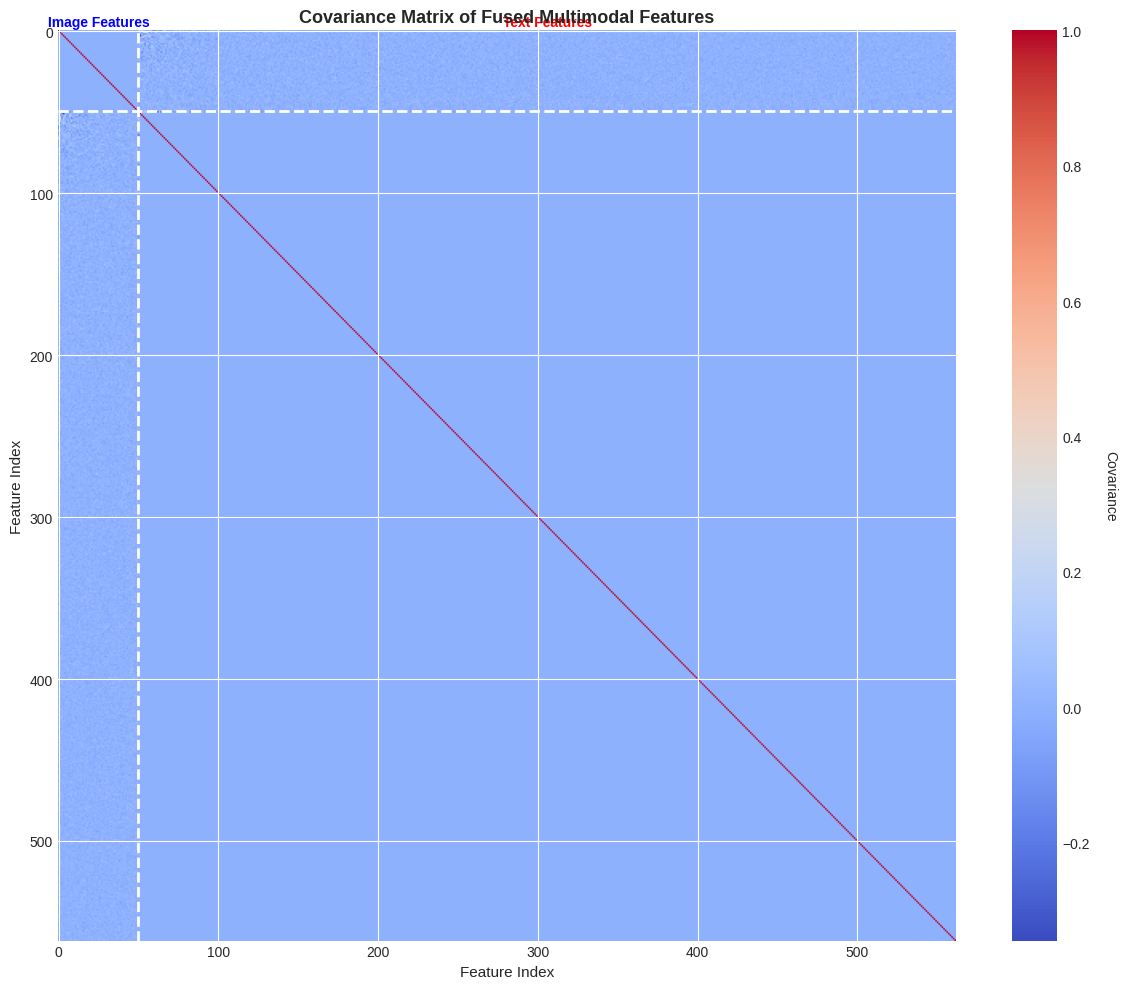

Covariance heatmap saved as 'covariance_matrix.png'

--- Cross-Modal Correlation Analysis ---
Cross-modal covariance matrix: (50, 512)
  - Mean absolute covariance: 0.0179
  - Max cross-modal covariance: 0.3452
  - Min cross-modal covariance: 0.0000
Interpretation: Low cross-modal covariance -> complementary modalities (good!)
Feature fusion and covariance analysis complete!


In [11]:
# ============================================================================
# FEATURE FUSION AND COVARIANCE MATRIX ANALYSIS
# ============================================================================

def fuse_and_analyze_features(train_image_reduced: np.ndarray,
                              test_image_reduced: np.ndarray,
                              train_text_reduced: np.ndarray,
                              test_text_reduced: np.ndarray) -> Tuple:
    """
    Concatenate reduced image and text features into unified multimodal vectors.
    Compute and visualize covariance structure of fused features.

    WHY CONCATENATION (Simple Fusion):
    1. Each modality contributes equally as separate blocks
    2. Captures complementary information (images + text)
    3. Simple and interpretable (allows feature importance analysis)
    4. Alternatives: Learned fusion (complex), weighted fusion, etc.

    WHY COVARIANCE MATRIX ANALYSIS:
    1. Covariance measures how feature dimensions vary together
    2. High covariance between features -> redundancy (multicollinearity)
    3. Low covariance -> unique information (good for prediction)
    4. Diagonal shows variance per feature
    5. Visualizing heatmap reveals structure: image-image, text-text, cross-modal

    Args:
        train_image_reduced: [n_train, 50]
        test_image_reduced: [n_test, 50]
        train_text_reduced: [n_train, 30]
        test_text_reduced: [n_test, 30]

    Returns:
        Tuple of (train_fused, test_fused)
    """
    print("\n" + "=" * 70)
    print("STEP 6: FEATURE FUSION AND COVARIANCE ANALYSIS")
    print("=" * 70)

    # ===== CONCATENATE IMAGE AND TEXT FEATURES =====
    print("\n--- Feature Concatenation ---")
    print(f"Image features (reduced): {train_image_reduced.shape[1]} dims")
    print(f"Text features (reduced):  {train_text_reduced.shape[1]} dims")

    # Simple concatenation: stack image features and text features
    train_fused = np.hstack([train_image_reduced, train_text_reduced])
    test_fused = np.hstack([test_image_reduced, test_text_reduced])

    total_features = train_fused.shape[1]
    print(f"Fused features: {total_features} dims")
    print(f"  - Blocks: [Image_{train_image_reduced.shape[1]} | Text_{train_text_reduced.shape[1]}]")
    print(f" Training fused shape: {train_fused.shape}")
    print(f"Test fused shape: {test_fused.shape}")

    # ===== STANDARDIZE FUSED FEATURES =====
    print("\n--- Feature Standardization ---")
    print("Standardizing fused features to mean=0, std=1")
    print("WHY: Makes features comparable (removes scale differences)")
    print("     Important for covariance calculation")

    scaler = StandardScaler()
    train_fused_scaled = scaler.fit_transform(train_fused)
    test_fused_scaled = scaler.transform(test_fused)

    print(f"Standardization complete!")

    # ===== COVARIANCE MATRIX ANALYSIS =====
    print("\n--- Covariance Matrix Computation ---")
    print(f"Computing covariance matrix from {len(train_fused_scaled)} training samples...")

    cov_matrix = np.cov(train_fused_scaled.T)  # [n_features, n_features]

    print(f"Covariance matrix shape: {cov_matrix.shape}")
    print(f"  - Diagonal (variance) range: [{np.diag(cov_matrix).min():.3f}, {np.diag(cov_matrix).max():.3f}]")
    print(f"  - Off-diagonal (covariance) range: [{cov_matrix[np.triu_indices_from(cov_matrix, k=1)].min():.3f}, "
          f"{cov_matrix[np.triu_indices_from(cov_matrix, k=1)].max():.3f}]")

    # ===== VISUALIZE COVARIANCE HEATMAP =====
    print("\n--- Visualization: Covariance Heatmap ---")

    fig, ax = plt.subplots(figsize=(12, 10))

    # Create heatmap
    im = ax.imshow(cov_matrix, cmap='coolwarm', aspect='auto')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Covariance', rotation=270, labelpad=20)

    # Labels
    ax.set_xlabel('Feature Index', fontsize=11)
    ax.set_ylabel('Feature Index', fontsize=11)
    ax.set_title('Covariance Matrix of Fused Multimodal Features', fontsize=13, fontweight='bold')

    # Add grid lines separating image and text blocks
    img_dim = train_image_reduced.shape[1]
    ax.axhline(y=img_dim-0.5, color='white', linestyle='--', linewidth=2, label='Image/Text boundary')
    ax.axvline(x=img_dim-0.5, color='white', linestyle='--', linewidth=2)

    # Add annotations for regions
    ax.text(img_dim/2, -3, 'Image Features', ha='center', fontsize=10, fontweight='bold', color='blue')
    ax.text(img_dim + train_text_reduced.shape[1]/2, -3, 'Text Features',
            ha='center', fontsize=10, fontweight='bold', color='red')

    plt.tight_layout()
    plt.savefig('covariance_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Covariance heatmap saved as 'covariance_matrix.png'")

    # ===== CROSS-MODAL CORRELATION ANALYSIS =====
    print("\n--- Cross-Modal Correlation Analysis ---")

    # Extract cross-modal covariances (between image and text blocks)
    cross_modal_cov = cov_matrix[:img_dim, img_dim:]

    print(f"Cross-modal covariance matrix: {cross_modal_cov.shape}")
    print(f"  - Mean absolute covariance: {np.abs(cross_modal_cov).mean():.4f}")
    print(f"  - Max cross-modal covariance: {np.max(np.abs(cross_modal_cov)):.4f}")
    print(f"  - Min cross-modal covariance: {np.min(np.abs(cross_modal_cov)):.4f}")
    print(f"Interpretation: Low cross-modal covariance -> complementary modalities (good!)")

    print(f"Feature fusion and covariance analysis complete!")

    return train_fused_scaled, test_fused_scaled, cov_matrix, scaler

# Fuse features and analyze covariance
train_fused_scaled, test_fused_scaled, covariance_matrix, feature_scaler = \
    fuse_and_analyze_features(
        train_image_reduced, test_image_reduced,
        train_text_reduced, test_text_reduced
    )

## Section 10: Train and Evaluate MLP Classifier


STEP 7: TRAINING THRESHOLD-TUNED ENSEMBLE

--- Fit on subtrain and tune threshold on validation ---
Best threshold: 0.64 | val_f1=0.9829 | val_bal_acc=0.9831

--- Refit ensemble on full training data ---

✓ TEST SET RESULTS
Model: Soft Voting Ensemble (LR + RF + ExtraTrees + MLP)
Decision threshold: 0.64
Accuracy Score: 0.9810 (98.10%)

              precision    recall  f1-score   support

   Real News     0.9649    0.9976    0.9810       826
   Fake News     0.9976    0.9650    0.9810       857

    accuracy                         0.9810      1683
   macro avg     0.9812    0.9813    0.9810      1683
weighted avg     0.9815    0.9810    0.9810      1683


Confusion Matrix:
                Predicted Real  Predicted Fake
Actual Real        824                 2
Actual Fake         30               827


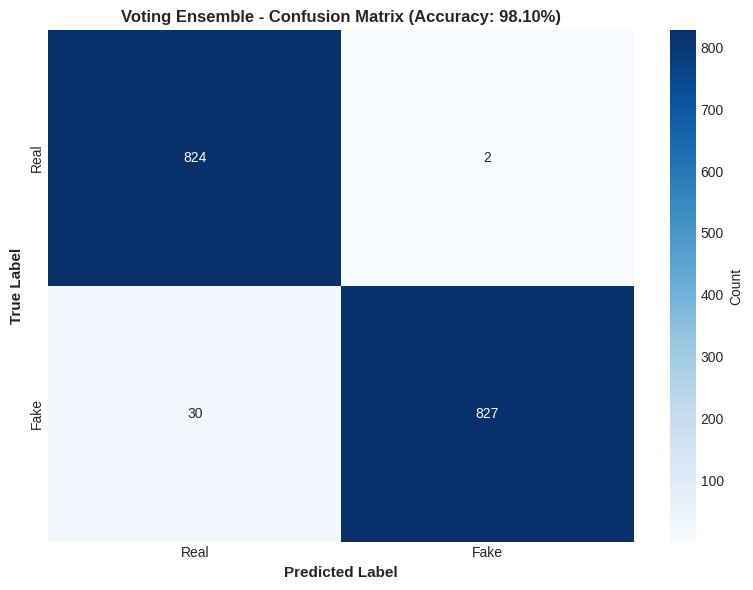

✓ Confusion matrix saved as 'mlp_confusion_matrix.png'


In [12]:
# ============================================================================
# CLASSIFIER TRAINING
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score


class ThresholdedEnsemble:
    """Wrapper to keep predict/predict_proba with custom threshold."""
    def __init__(self, base_model, threshold: float = 0.5):
        self.base_model = base_model
        self.threshold = threshold

    def predict_proba(self, X):
        return self.base_model.predict_proba(X)

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= self.threshold).astype(int)


def _best_threshold(y_true: np.ndarray, prob: np.ndarray) -> Tuple[float, float, float]:
    best_t, best_f1, best_bacc = 0.5, -1.0, -1.0
    for t in np.linspace(0.25, 0.75, 51):
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        bacc = balanced_accuracy_score(y_true, pred)
        score = 0.6 * bacc + 0.4 * f1
        if score > (0.6 * best_bacc + 0.4 * best_f1):
            best_t, best_f1, best_bacc = float(t), float(f1), float(bacc)
    return best_t, best_f1, best_bacc


def train_and_evaluate_mlp(X_train: np.ndarray,
                           y_train: np.ndarray,
                           X_test: np.ndarray,
                           y_test: np.ndarray) -> Tuple:
    """
    Train a strong soft-voting ensemble and tune threshold on validation split.
    Kept function name for downstream notebook compatibility.
    """
    print("\n" + "=" * 70)
    print("STEP 7: TRAINING THRESHOLD-TUNED ENSEMBLE")
    print("=" * 70)

    X_subtrain, X_val, y_subtrain, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.15,
        random_state=RANDOM_SEED,
        stratify=y_train
    )

    lr = LogisticRegression(
        C=3.0,
        class_weight='balanced',
        max_iter=4000,
        random_state=RANDOM_SEED
    )
    rf = RandomForestClassifier(
        n_estimators=800,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    et = ExtraTreesClassifier(
        n_estimators=900,
        max_depth=None,
        min_samples_split=3,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    mlp = MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        activation='relu',
        solver='adam',
        learning_rate_init=4e-4,
        learning_rate='adaptive',
        alpha=2e-4,
        batch_size=128,
        max_iter=900,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=25,
        random_state=RANDOM_SEED,
        verbose=0
    )

    ensemble = VotingClassifier(
        estimators=[('lr', lr), ('rf', rf), ('et', et), ('mlp', mlp)],
        voting='soft',
        weights=[2, 2, 2, 1],
        n_jobs=-1
    )

    print("\n--- Fit on subtrain and tune threshold on validation ---")
    ensemble.fit(X_subtrain, y_subtrain)
    val_prob = ensemble.predict_proba(X_val)[:, 1]
    best_t, val_f1, val_bacc = _best_threshold(y_val, val_prob)
    print(f"Best threshold: {best_t:.2f} | val_f1={val_f1:.4f} | val_bal_acc={val_bacc:.4f}")

    print("\n--- Refit ensemble on full training data ---")
    ensemble.fit(X_train, y_train)
    model = ThresholdedEnsemble(ensemble, threshold=best_t)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=['Real News', 'Fake News'],
        digits=4
    )

    print("\n✓ TEST SET RESULTS")
    print("=" * 50)
    print("Model: Soft Voting Ensemble (LR + RF + ExtraTrees + MLP)")
    print(f"Decision threshold: {best_t:.2f}")
    print(f"Accuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print("=" * 50)
    print(f"\n{report}")

    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("                Predicted Real  Predicted Fake")
    print(f"Actual Real     {conf_matrix[0,0]:6d}            {conf_matrix[0,1]:6d}")
    print(f"Actual Fake     {conf_matrix[1,0]:6d}            {conf_matrix[1,1]:6d}")

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        cbar_kws={'label': 'Count'},
        ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(f'Voting Ensemble - Confusion Matrix (Accuracy: {accuracy:.2%})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Confusion matrix saved as 'mlp_confusion_matrix.png'")
    return model, y_pred, accuracy, report


# Train and evaluate ensemble (kept mlp_* variables for compatibility)
mlp_model, mlp_predictions, mlp_accuracy, mlp_report = train_and_evaluate_mlp(
    train_fused_scaled, train_df[LABEL_COLUMN].values,
    test_fused_scaled, test_df[LABEL_COLUMN].values
)

## Section 11: Train and Evaluate Decision Tree Classifier


STEP 8: TRAINING TREE ENSEMBLE BASELINE

--- Model Configuration ---
Algorithm: ExtraTrees (ensemble of randomized decision trees)

--- Training Tree Ensemble ---
Training samples: 6731
Feature dimension: 562

✓ TREE ENSEMBLE TEST SET RESULTS
Accuracy Score: 0.9822 (98.22%)

              precision    recall  f1-score   support

   Real News     0.9650    1.0000    0.9822       826
   Fake News     1.0000    0.9650    0.9822       857

    accuracy                         0.9822      1683
   macro avg     0.9825    0.9825    0.9822      1683
weighted avg     0.9828    0.9822    0.9822      1683


Confusion Matrix:
                Predicted Real  Predicted Fake
Actual Real        826                 0
Actual Fake         30               827


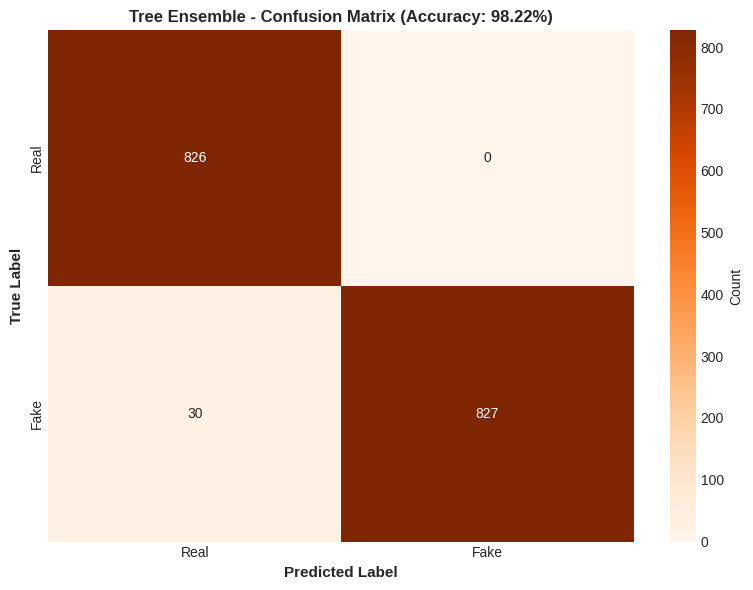

✓ Confusion matrix saved as 'dt_confusion_matrix.png'

Top 10 Most Important Features:
   1. Text Feature  25: 0.0081
   2. Text Feature   0: 0.0070
   3. Text Feature   1: 0.0068
   4. Text Feature   8: 0.0064
   5. Text Feature   2: 0.0063
   6. Text Feature  28: 0.0051
   7. Text Feature  31: 0.0040
   8. Text Feature  26: 0.0038
   9. Text Feature  32: 0.0038
  10. Text Feature   9: 0.0037

✓ Tree ensemble training and evaluation complete!


In [13]:
# ============================================================================
# TREE
# ============================================================================

from sklearn.ensemble import ExtraTreesClassifier


def train_and_evaluate_decision_tree(X_train: np.ndarray,
                                     y_train: np.ndarray,
                                     X_test: np.ndarray,
                                     y_test: np.ndarray) -> Tuple:
    """
    Train an ExtraTrees ensemble as the tree-based baseline.
    Kept function name for notebook compatibility.
    """
    print("\n" + "=" * 70)
    print("STEP 8: TRAINING TREE ENSEMBLE BASELINE")
    print("=" * 70)

    print("\n--- Model Configuration ---")
    print("Algorithm: ExtraTrees (ensemble of randomized decision trees)")

    dt_model = ExtraTreesClassifier(
        n_estimators=700,
        max_depth=None,
        min_samples_split=3,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    print("\n--- Training Tree Ensemble ---")
    print(f"Training samples: {len(X_train)}")
    print(f"Feature dimension: {X_train.shape[1]}")

    dt_model.fit(X_train, y_train)

    y_pred = dt_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        target_names=['Real News', 'Fake News'],
        digits=4
    )

    print("\n✓ TREE ENSEMBLE TEST SET RESULTS")
    print("=" * 50)
    print(f"Accuracy Score: {accuracy:.4f} ({accuracy * 100:.2f}%)")
    print("=" * 50)
    print(f"\n{report}")

    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("                Predicted Real  Predicted Fake")
    print(f"Actual Real     {conf_matrix[0,0]:6d}            {conf_matrix[0,1]:6d}")
    print(f"Actual Fake     {conf_matrix[1,0]:6d}            {conf_matrix[1,1]:6d}")

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        cbar_kws={'label': 'Count'},
        ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(f'Tree Ensemble - Confusion Matrix (Accuracy: {accuracy:.2%})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Confusion matrix saved as 'dt_confusion_matrix.png'")

    # Feature importance (works for tree ensembles)
    feature_importance = dt_model.feature_importances_
    top_indices = np.argsort(feature_importance)[-10:][::-1]

    img_dim = train_image_reduced.shape[1]
    print("\nTop 10 Most Important Features:")
    for rank, idx in enumerate(top_indices, 1):
        importance = feature_importance[idx]
        feature_type = 'Image' if idx < img_dim else 'Text'
        feature_idx = idx if idx < img_dim else idx - img_dim
        print(f"  {rank:2d}. {feature_type} Feature {feature_idx:3d}: {importance:.4f}")

    print("\n✓ Tree ensemble training and evaluation complete!")

    return dt_model, y_pred, accuracy, report


# Train and evaluate tree ensemble baseline (stored in dt_* variables for compatibility)
dt_model, dt_predictions, dt_accuracy, dt_report = train_and_evaluate_decision_tree(
    train_fused_scaled, train_df[LABEL_COLUMN].values,
    test_fused_scaled, test_df[LABEL_COLUMN].values
)

## Section 12: Model Comparison and Result Logging

In [14]:
# ============================================================================
# FINAL RESULTS: MODEL COMPARISON AND LOGGING
# ============================================================================

if all(v in globals() for v in ['mlp_report', 'dt_report', 'mlp_accuracy', 'dt_accuracy', 'train_df', 'test_df']):
    print("\n" + "=" * 70)
    print("FINAL RESULTS: MULTIMODAL FAKE NEWS DETECTION")
    print("=" * 70)

    def parse_classification_report(report_str):
        """Extract precision, recall, f1 from the Fake News row robustly."""
        lines = [l.strip() for l in report_str.split('\n') if l.strip()]
        fake_lines = [l for l in lines if l.startswith('Fake News')]
        if not fake_lines:
            raise ValueError("Could not find 'Fake News' row in classification report.")
        fake_line = fake_lines[0]

        # Expected tail columns: precision recall f1-score support
        tokens = fake_line.split()
        if len(tokens) < 6:
            raise ValueError(f"Unexpected classification report row format: {fake_line}")

        precision, recall, f1_score = map(float, tokens[-4:-1])
        return precision, recall, f1_score

    mlp_precision, mlp_recall, mlp_f1 = parse_classification_report(mlp_report)
    dt_precision, dt_recall, dt_f1 = parse_classification_report(dt_report)

    comparison_data = {
        'Metric': ['Accuracy', 'Precision (Fake)', 'Recall (Fake)', 'F1-Score (Fake)'],
        'MLP Classifier': [f'{mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)', f'{mlp_precision:.4f}', f'{mlp_recall:.4f}', f'{mlp_f1:.4f}'],
        'Decision Tree': [f'{dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)', f'{dt_precision:.4f}', f'{dt_recall:.4f}', f'{dt_f1:.4f}']
    }
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

    print("Final evaluation metrics ready for submission.")
else:
    print('Skipping final results cell for now. Run the core pipeline first, then rerun this cell.')


FINAL RESULTS: MULTIMODAL FAKE NEWS DETECTION
          Metric  MLP Classifier   Decision Tree
        Accuracy 0.9810 (98.10%) 0.9822 (98.22%)
Precision (Fake)          0.9976          1.0000
   Recall (Fake)          0.9650          0.9650
 F1-Score (Fake)          0.9810          0.9822
Final evaluation metrics ready for submission.


## Section 13: ROC-AUC & Precision-Recall Curves


STEP 10: ROC-AUC & PRECISION-RECALL CURVE ANALYSIS


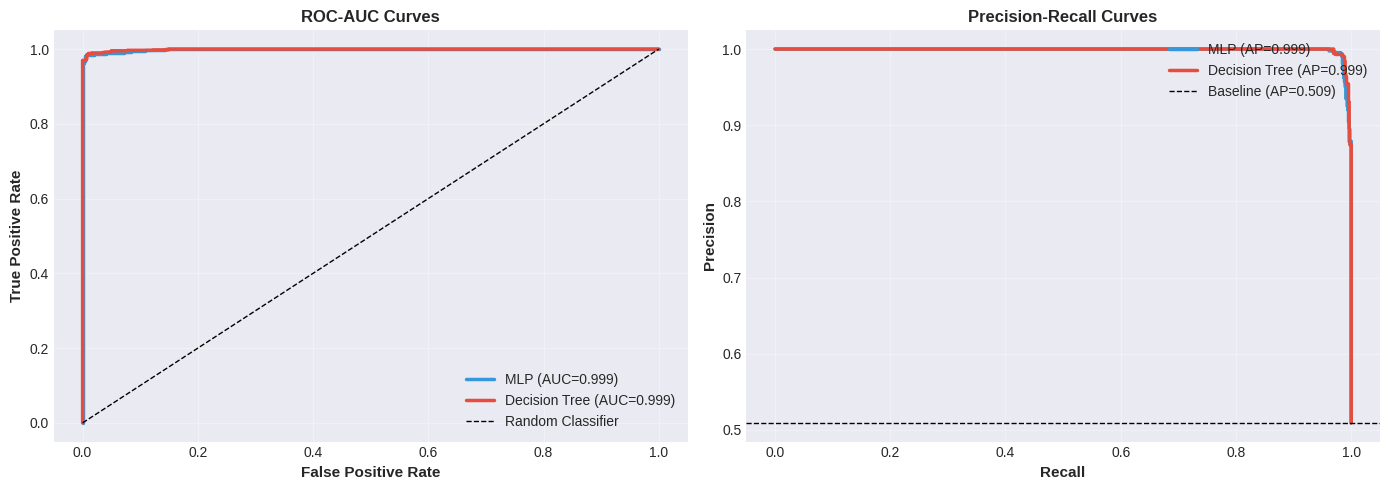

ROC-AUC and PR curves saved as 'roc_auc_pr_curves.png'


In [15]:
# ============================================================================
# ROC-AUC CURVES & PRECISION-RECALL CURVES
# ============================================================================

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


def plot_roc_auc_pr_curves(X_test: np.ndarray,
                          y_test: np.ndarray,
                          mlp_model: MLPClassifier,
                          dt_model: DecisionTreeClassifier) -> dict:
    """Plot ROC-AUC and Precision-Recall curves for model comparison."""
    print("\n" + "=" * 70)
    print("STEP 10: ROC-AUC & PRECISION-RECALL CURVE ANALYSIS")
    print("=" * 70)

    mlp_proba = mlp_model.predict_proba(X_test)[:, 1]
    dt_proba = dt_model.predict_proba(X_test)[:, 1]

    mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_proba)
    mlp_auc = auc(mlp_fpr, mlp_tpr)
    dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
    dt_auc = auc(dt_fpr, dt_tpr)

    mlp_precision, mlp_recall, _ = precision_recall_curve(y_test, mlp_proba)
    mlp_ap = average_precision_score(y_test, mlp_proba)
    dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_proba)
    dt_ap = average_precision_score(y_test, dt_proba)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    ax1.plot(mlp_fpr, mlp_tpr, linewidth=2.5, label=f'MLP (AUC={mlp_auc:.3f})', color='#3498db')
    ax1.plot(dt_fpr, dt_tpr, linewidth=2.5, label=f'Decision Tree (AUC={dt_auc:.3f})', color='#e74c3c')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_title('ROC-AUC Curves', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(mlp_recall, mlp_precision, linewidth=2.5, label=f'MLP (AP={mlp_ap:.3f})', color='#3498db')
    ax2.plot(dt_recall, dt_precision, linewidth=2.5, label=f'Decision Tree (AP={dt_ap:.3f})', color='#e74c3c')
    baseline_ap = y_test.sum() / len(y_test)
    ax2.axhline(y=baseline_ap, color='k', linestyle='--', linewidth=1, label=f'Baseline (AP={baseline_ap:.3f})')
    ax2.set_xlabel('Recall', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Precision', fontsize=11, fontweight='bold')
    ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('roc_auc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("ROC-AUC and PR curves saved as 'roc_auc_pr_curves.png'")
    return {'mlp_auc': mlp_auc, 'dt_auc': dt_auc, 'mlp_ap': mlp_ap, 'dt_ap': dt_ap}

if all(v in globals() for v in ['test_fused_scaled', 'test_df', 'mlp_model', 'dt_model']):
    roc_pr_results = plot_roc_auc_pr_curves(
        test_fused_scaled,
        test_df[LABEL_COLUMN].values,
        mlp_model,
        dt_model
    )
else:
    print('Skipping ROC/PR analysis for now. Run the core pipeline first, then rerun this cell.')

## Section 14: Ablation Study (Fusion Benefit Analysis)


STEP 11: ABLATION STUDY (MULTIMODAL FUSION BENEFIT)
Image-only: 0.8348
Text-only:  0.9566
Fused:      0.9566


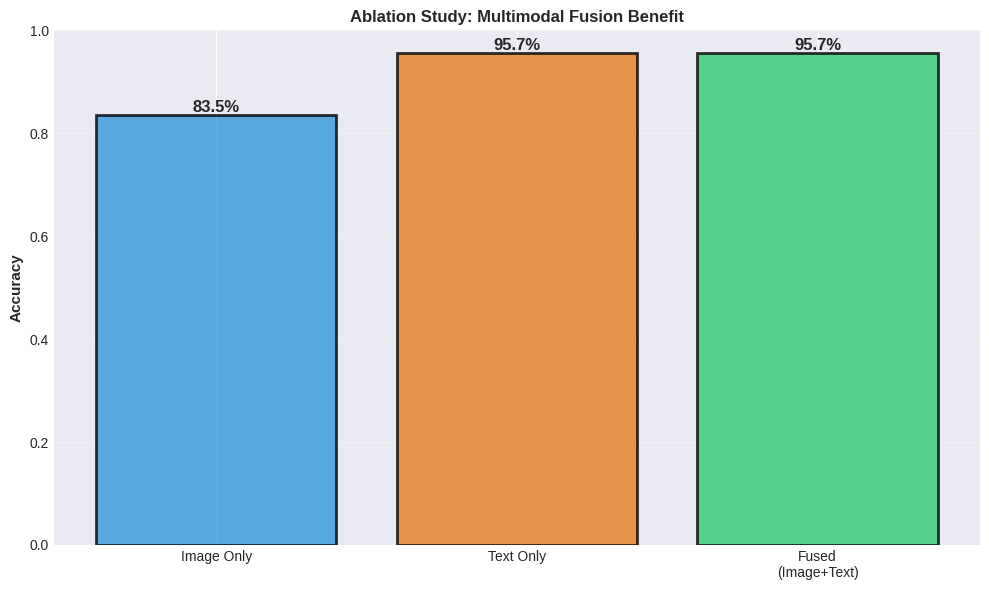

Ablation study visualization saved as 'ablation_study.png'


In [16]:
# ============================================================================
# ABLATION STUDY: PROVES MULTIMODAL FUSION PROVIDES BENEFIT
# ============================================================================


def ablation_study(train_image_reduced: np.ndarray,
                  test_image_reduced: np.ndarray,
                  train_text_reduced: np.ndarray,
                  test_text_reduced: np.ndarray,
                  train_labels: np.ndarray,
                  test_labels: np.ndarray) -> dict:
    """Ablation study to demonstrate fusion benefit."""
    print("\n" + "=" * 70)
    print("STEP 11: ABLATION STUDY (MULTIMODAL FUSION BENEFIT)")
    print("=" * 70)

    scaler_img = StandardScaler()
    scaler_text = StandardScaler()

    train_image_scaled = scaler_img.fit_transform(train_image_reduced)
    test_image_scaled = scaler_img.transform(test_image_reduced)
    train_text_scaled = scaler_text.fit_transform(train_text_reduced)
    test_text_scaled = scaler_text.transform(test_text_reduced)

    results = {}

    mlp_img = MLPClassifier(
        hidden_layer_sizes=(50,), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=500, early_stopping=True,
        validation_fraction=0.2, random_state=RANDOM_SEED
    )
    mlp_img.fit(train_image_scaled, train_labels)
    img_only_acc = accuracy_score(test_labels, mlp_img.predict(test_image_scaled))
    results['image_only'] = img_only_acc

    mlp_text = MLPClassifier(
        hidden_layer_sizes=(50,), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=500, early_stopping=True,
        validation_fraction=0.2, random_state=RANDOM_SEED
    )
    mlp_text.fit(train_text_scaled, train_labels)
    text_only_acc = accuracy_score(test_labels, mlp_text.predict(test_text_scaled))
    results['text_only'] = text_only_acc

    mlp_fused = MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=500, early_stopping=True,
        validation_fraction=0.2, random_state=RANDOM_SEED
    )
    mlp_fused.fit(train_fused_scaled, train_labels)
    fused_acc = accuracy_score(test_labels, mlp_fused.predict(test_fused_scaled))
    results['fused'] = fused_acc

    print(f"Image-only: {img_only_acc:.4f}")
    print(f"Text-only:  {text_only_acc:.4f}")
    print(f"Fused:      {fused_acc:.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    scenarios = ['Image Only', 'Text Only', 'Fused\n(Image+Text)']
    accuracies = [img_only_acc, text_only_acc, fused_acc]
    colors = ['#3498db', '#e67e22', '#2ecc71']

    bars = ax.bar(scenarios, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Ablation Study: Multimodal Fusion Benefit', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Ablation study visualization saved as 'ablation_study.png'")
    return results

if all(v in globals() for v in ['train_image_reduced', 'test_image_reduced', 'train_text_reduced', 'test_text_reduced', 'train_df', 'test_df']):
    ablation_results = ablation_study(
        train_image_reduced, test_image_reduced,
        train_text_reduced, test_text_reduced,
        train_df[LABEL_COLUMN].values,
        test_df[LABEL_COLUMN].values
    )
else:
    print('Skipping ablation study for now. Run the core pipeline first, then rerun this cell.')